# 0. Imports

In [1]:
#!pip install -qq ipython numpy pandas scikit-learn statsmodels xgboost torch

In [2]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import numpy as np
import pandas as pd

import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from collections import Counter
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform


In [3]:
!python --version
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scikit-learn", sklearn.__version__)

Python 3.10.18
numpy 2.2.6
pandas 2.3.3
scikit-learn 1.7.2


# 1. Preprocessing

In [4]:
# AUTOREGRESSIVE (LAG) FEATURES

lags = sorted(set(
    list(range(1, 7)) + [12, 18]
    + list(range(24, 27)) + [36, 48]
    + [24*i for i in range(3,7)]
    + [24*7*i for i in range(1,5)]
))
lagFeatures = [f"Adjusted demand -{h} hr" for h in lags]

In [5]:
# CALENDAR FEATURES

# Raw integer calendar features
intDateTimeFeatures = ["Hour", "Month", "DayOfWeek", "DayOfYear"]

# Low order hour of day and day of year Fourier term features
hourFourierFeatures, dayFourierFeatures = [], []
for i in (1, 2, 3):
    argStr = (f"{i}*" if i>1 else "") + "Hour"
    hourFourierFeatures.extend([f"sin({argStr})", f"cos({argStr})"])
    argStr = (f"{i}*" if i>1 else "") + "DayOfYear"
    dayFourierFeatures.extend([f"sin({argStr})", f"cos({argStr})"])

# Hour of day and day of week one-hot encodings.
# Weekend and holiday flags.
hourDummyFeatures = [f"Hour_Flag_{h}" for h in range(24)]
dayDummyFeatures = ["Day_Flag_Weekend", "Day_Flag_Holiday"]
dayDummyFeatures += [f"DayOfWeek_Flag_{d}" for d in range(7)]
monthDummyFeatures = [f"Month_Flag_{m}" for m in range(1, 13)]

# Collate all calendar features
calendarFeatures = (
    intDateTimeFeatures
    + hourFourierFeatures
    + dayFourierFeatures
    + hourDummyFeatures
    + dayDummyFeatures
    + monthDummyFeatures
)


In [6]:
# ENERGY FEATURES

energyFeatures = [
    # "Adjusted net generation",
    "Adjusted total interchange",
    "FPC", "FMPP", "SOCO", "TEC",
    "JEA", "SEC", "HST", "GVL",
]


In [7]:
# WEATHER FEATURES

skyCodes = ['BKN', 'CLR', 'FEW', 'SCT', 'OVC', 'NA']
directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "VRB"]

weatherFeatures = ([
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyRelativeHumidity",
    "HourlySeaLevelPressure",
    "HourlyVisibility",
    "HourlyWindSpeed"]
    + [f"HourlySkyConditions_Flag_{code}" for code in skyCodes]
    + [f"HourlyWindDirection_Flag_{d}" for d in directions]
    + ["sin(HourlyWindDirection)", "cos(HourlyWindDirection)"]
)


In [8]:
# Define other convenient feature variables.

target = "Adjusted demand"
allFeatures = (
    ['t', target]
    + lagFeatures 
    + calendarFeatures 
    + energyFeatures 
    + weatherFeatures
)
someFeatures = (
    ['t', target]
    + lagFeatures[:6] 
    + hourFourierFeatures[:2] + dayFourierFeatures[:2] + dayDummyFeatures[:1]
    + energyFeatures[:2] 
    + weatherFeatures[:12]
)


### 1.3 Data Splits

In [9]:
# reproducibility
np.random.seed(42)

# --- paths ---
data_root   = Path("data/clean")
train_dir   = data_root / "train"
val_dir     = data_root / "val"

DFtrain = pd.read_pickle(train_dir / "DFtrain.pkl")
DFval   = pd.read_pickle(val_dir   / "DFval.pkl")

# --- define target and features (ADJUST target name to yours) ---
TARGET_COL   = "Adjusted demand"   # <--- change to your target column
TIME_COL     = "t"        # if you have a time column
FEATURE_COLS = someFeatures[2:]

print("n_train:", len(DFtrain), "n_val:", len(DFval))
print("n_features:", len(FEATURE_COLS))

n_train: 59658 n_val: 12784
n_features: 25


Feature importance scores:
 [9.43757286e-01 3.72761792e-03 2.24285364e-03 1.27058728e-03
 8.45627413e-04 6.77317397e-04 3.51903568e-03 3.57770891e-02
 5.64042675e-04 5.68983799e-04 2.95811612e-04 6.37911950e-04
 6.95928757e-04 3.91855824e-03 7.23752865e-05 3.33254779e-04
 3.79530906e-04 1.60321768e-04 3.03159338e-04 5.66839937e-05
 2.40943152e-05 4.20007122e-05 5.20893203e-05 4.58943688e-05
 3.19442399e-05]


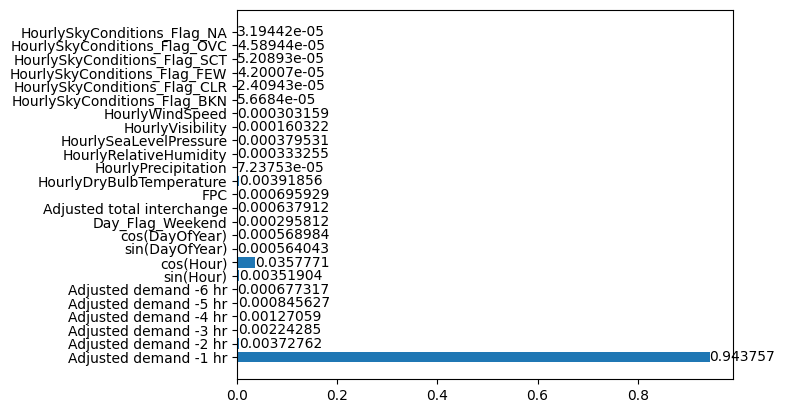

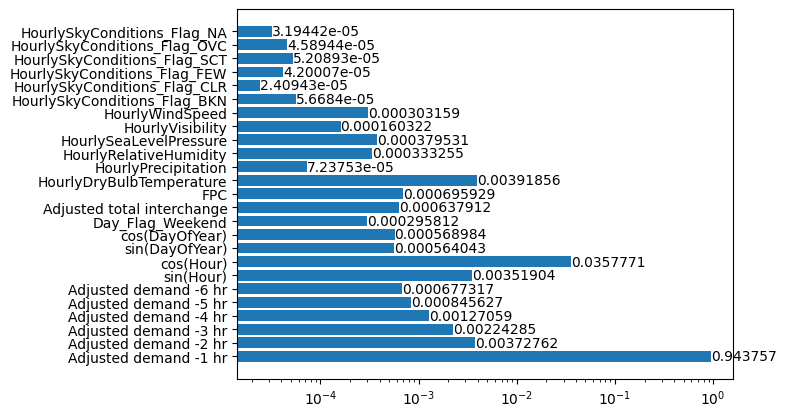

In [10]:
# --- New from Edward ---

# Load feature selection raw data
X_fs = DFtrain[FEATURE_COLS]
y_fs = DFtrain[TARGET_COL]


# Fit random forest model
fs_model = RandomForestRegressor(n_estimators=50, random_state=42)
fs_model.fit(X_fs, y_fs)


# Show feature importance scores
print("Feature importance scores:\n", fs_model.feature_importances_)


# Plot feature importance scores
fs_plot_names = FEATURE_COLS
fs_plot_ticks = fs_plot_names

fig, ax = plt.subplots()
bars = ax.barh(fs_plot_ticks, fs_model.feature_importances_)
ax.bar_label(bars)
ax.set_yticks(fs_plot_ticks, fs_plot_names)
ax.set_xscale('linear')
plt.show()

fig, ax = plt.subplots()
bars = ax.barh(fs_plot_ticks, fs_model.feature_importances_)
ax.bar_label(bars)
ax.set_yticks(fs_plot_ticks, fs_plot_names)
ax.set_xscale('log')
plt.show()

# --- New from Edward ---

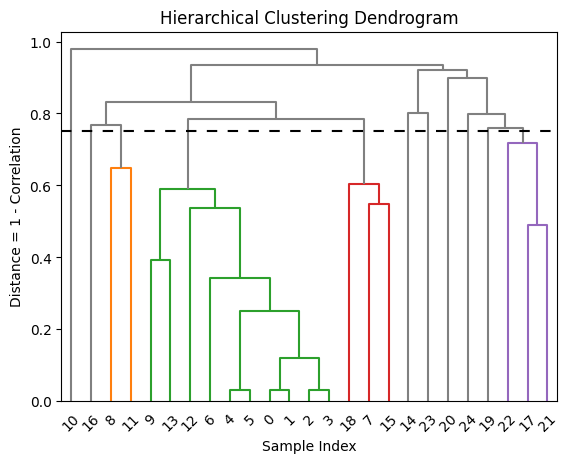

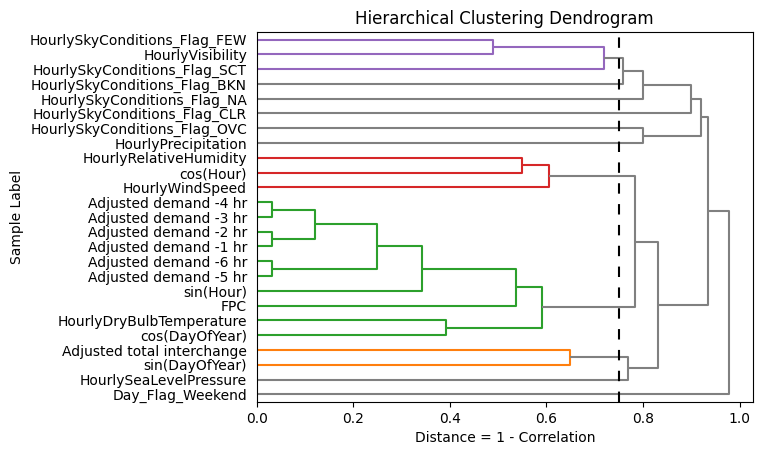

Flat Clusters : [ 3  3  3  3  3  3  3  4  1  3 11  1  3  3  5  4  2  7  4  8 10  7  7  6
  9]
Cluster 1 : ['sin(DayOfYear)', 'Adjusted total interchange']
Cluster 2 : ['HourlySeaLevelPressure']
Cluster 3 : ['Adjusted demand -1 hr', 'Adjusted demand -2 hr', 'Adjusted demand -3 hr', 'Adjusted demand -4 hr', 'Adjusted demand -5 hr', 'Adjusted demand -6 hr', 'sin(Hour)', 'cos(DayOfYear)', 'FPC', 'HourlyDryBulbTemperature']
Cluster 4 : ['cos(Hour)', 'HourlyRelativeHumidity', 'HourlyWindSpeed']
Cluster 5 : ['HourlyPrecipitation']
Cluster 6 : ['HourlySkyConditions_Flag_OVC']
Cluster 7 : ['HourlyVisibility', 'HourlySkyConditions_Flag_FEW', 'HourlySkyConditions_Flag_SCT']
Cluster 8 : ['HourlySkyConditions_Flag_BKN']
Cluster 9 : ['HourlySkyConditions_Flag_NA']
Cluster 10 : ['HourlySkyConditions_Flag_CLR']
Cluster 11 : ['Day_Flag_Weekend']

Feature importance of cluster ['sin(DayOfYear)', 'Adjusted total interchange'] :
[0.38607452 0.61392548]
Feature importance of cluster ['HourlySeaLevelPressur

In [11]:
### 1.6 Feature Selection using SciPi

# --- New from Jonathan ---
DF_X = DFtrain[FEATURE_COLS]
DF_y = DFtrain[target]

fs_corr = DF_X.corr(method="spearman")
fs_dist = 1.0 - fs_corr.abs()

DF_clusters = linkage(squareform(fs_dist.values, checks=False), method="average")
# --- New from Jonathan ---



# --- New from Edward ---
fs_dist_max = 0.75 # Set maximum distance.



plt.figure()
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance = 1 - Correlation')
fs_dendrogram_v = dendrogram(DF_clusters, color_threshold=fs_dist_max, above_threshold_color='grey', orientation='top')
plt.axhline(y=fs_dist_max, c='k', dashes=(5,5))
plt.show()



plt.figure()
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Distance = 1 - Correlation')
plt.ylabel('Sample Label')
fs_dendrogram_h = dendrogram(DF_clusters, color_threshold=fs_dist_max, above_threshold_color='grey', orientation='right', labels=FEATURE_COLS)
plt.axvline(x=fs_dist_max, c='k', dashes=(5,5))
plt.show()




fs_fcluster = fcluster(DF_clusters, t=fs_dist_max, criterion='distance')
print('Flat Clusters :', fs_fcluster)
#print('Feature Names :', FEATURE_COLS)



allFeatsClusters = []
fs_num_clusters = len(Counter(fs_fcluster).keys())
fs_num_leaves = len(fs_fcluster)

for i in range(fs_num_clusters):
    allFeatsClusters.append([])

for i in range(fs_num_leaves):
    allFeatsClusters[fs_fcluster[i]-1].append(FEATURE_COLS[i])

for i in range(fs_num_clusters):
    print('Cluster', i+1, ':', allFeatsClusters[i])
print()


selectedFeats = []
y_fs_c = DFtrain[target]
for c in allFeatsClusters:
    if (len(c) < 1):
        print('Error: Cluster', c, 'has size < 1.')
        continue # Skip forward.
    elif (len(c) == 1):
        print('Feature importance of cluster', c, 'skipped with size = 1.')
        selectedFeats.append(c[0])
        continue # Skip forward.
    else:
        print('Feature importance of cluster', c, ':')
    
    # Load feature selection raw data
    X_fs_c = DFtrain[c]
    
    # Fit random forest model
    fs_c_model = RandomForestRegressor(n_estimators=50, random_state=42)
    fs_c_model.fit(X_fs_c, y_fs_c)
    
    # Show feature importance scores
    fs_c_importances = fs_c_model.feature_importances_
    print(fs_c_importances)
    
    # Select a feature with the highest importance
    fs_c_index = 0
    fs_c_importance_max = 0
    for i in range(len(fs_c_importances)):
        if (fs_c_importances[i] >= fs_c_importance_max):
            fs_c_importance_max = fs_c_importances[i]
            fs_c_index = i
    
    selectedFeats.append(c[fs_c_index])
print()



print('Selected features :', selectedFeats)
# --- New from Edward ---